In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/diyadholakia/yolov8-soc/xml2yolo.py
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels.cache
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/inclusion_4.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/pitted_surface_4.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/crazing_2.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/inclusion_2.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/crazing_1.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/scratches_4.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/inclusion_5.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/patches_3.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/rolled-in_scale_1.txt
/kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels/scratches_5.txt
/kaggle/input/datasets/diyadholakia/yolov8-s

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO
import pandas as pd
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
dataset_path = "/kaggle/input/datasets/diyadholakia/yolov8-soc"

print(os.listdir(dataset_path))

['xml2yolo.py', 'valid', 'train']


In [8]:
yaml_content = """
path: /kaggle/input/datasets/diyadholakia/yolov8-soc

train: train/train/images
val: valid/valid/images
test: test/test/images

nc: 6

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled_in_scale
  5: scratches
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [9]:
model = YOLO("yolov8s.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    cache=True,
    workers=2,
    pretrained=True,
    amp=True,
    project="runs",
    name="neu_yolo",
    exist_ok=True
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc2627e8830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [18]:
model = YOLO("runs/detect/runs/neu_yolo/weights/best.pt")
metrics = model.val(data="data.yaml")

print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.0±0.6 ms, read: 21.8±11.7 MB/s, size: 13.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 463.6it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 1.0s1.5s
                   all         30         64      0.613      0.773      0.783      0.475
               crazing          5          8      0.538        0.5      0.529      0.209
       

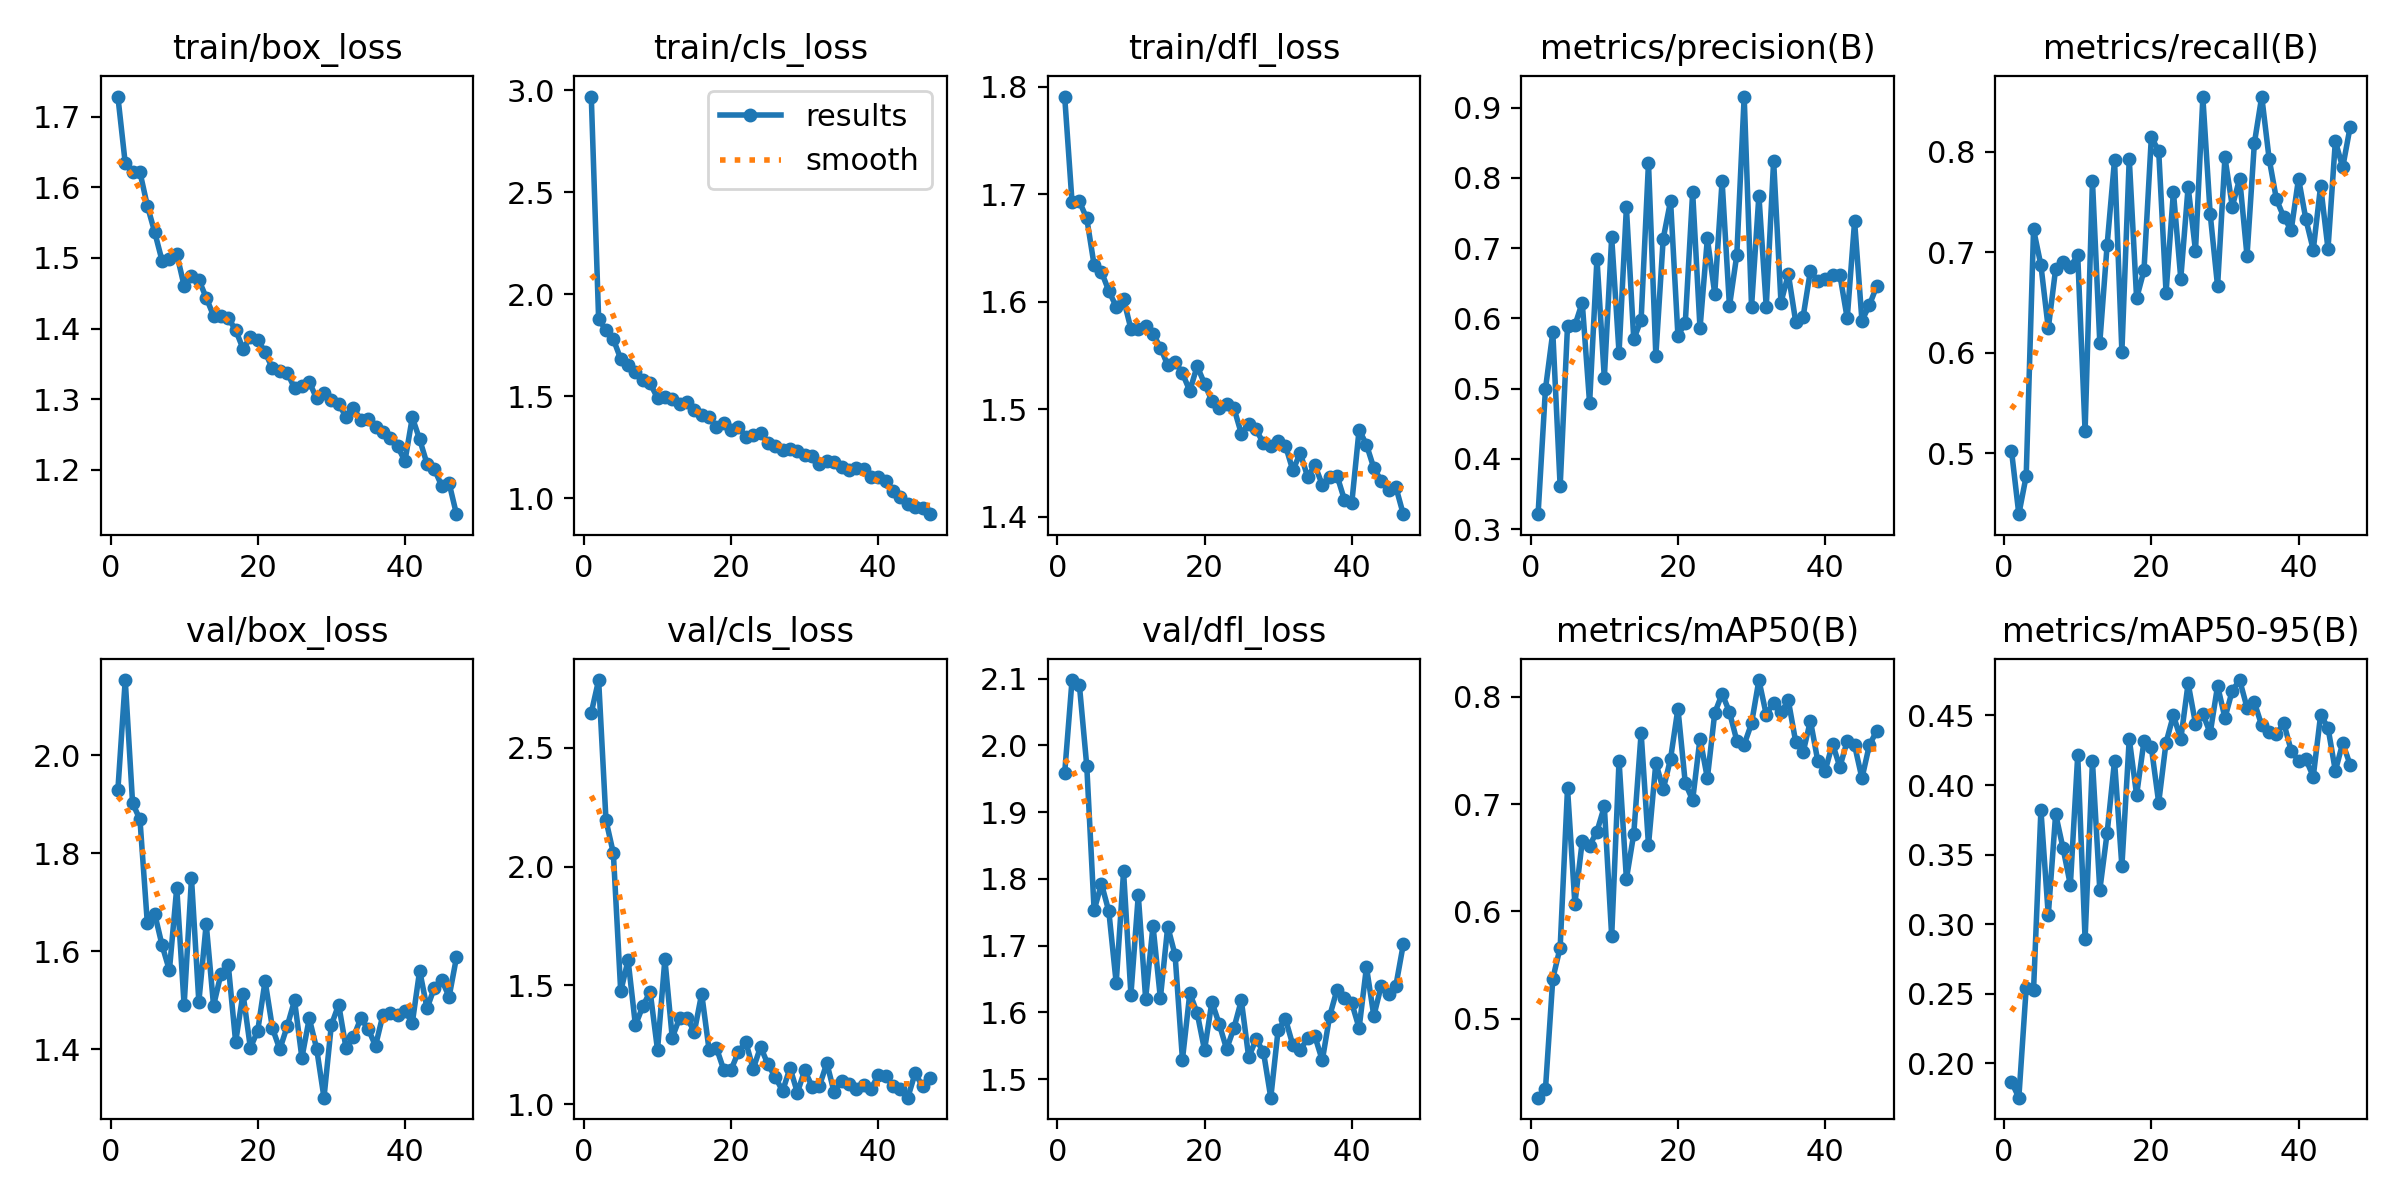

In [15]:
Image.open("runs/detect/runs/neu_yolo/results.png")

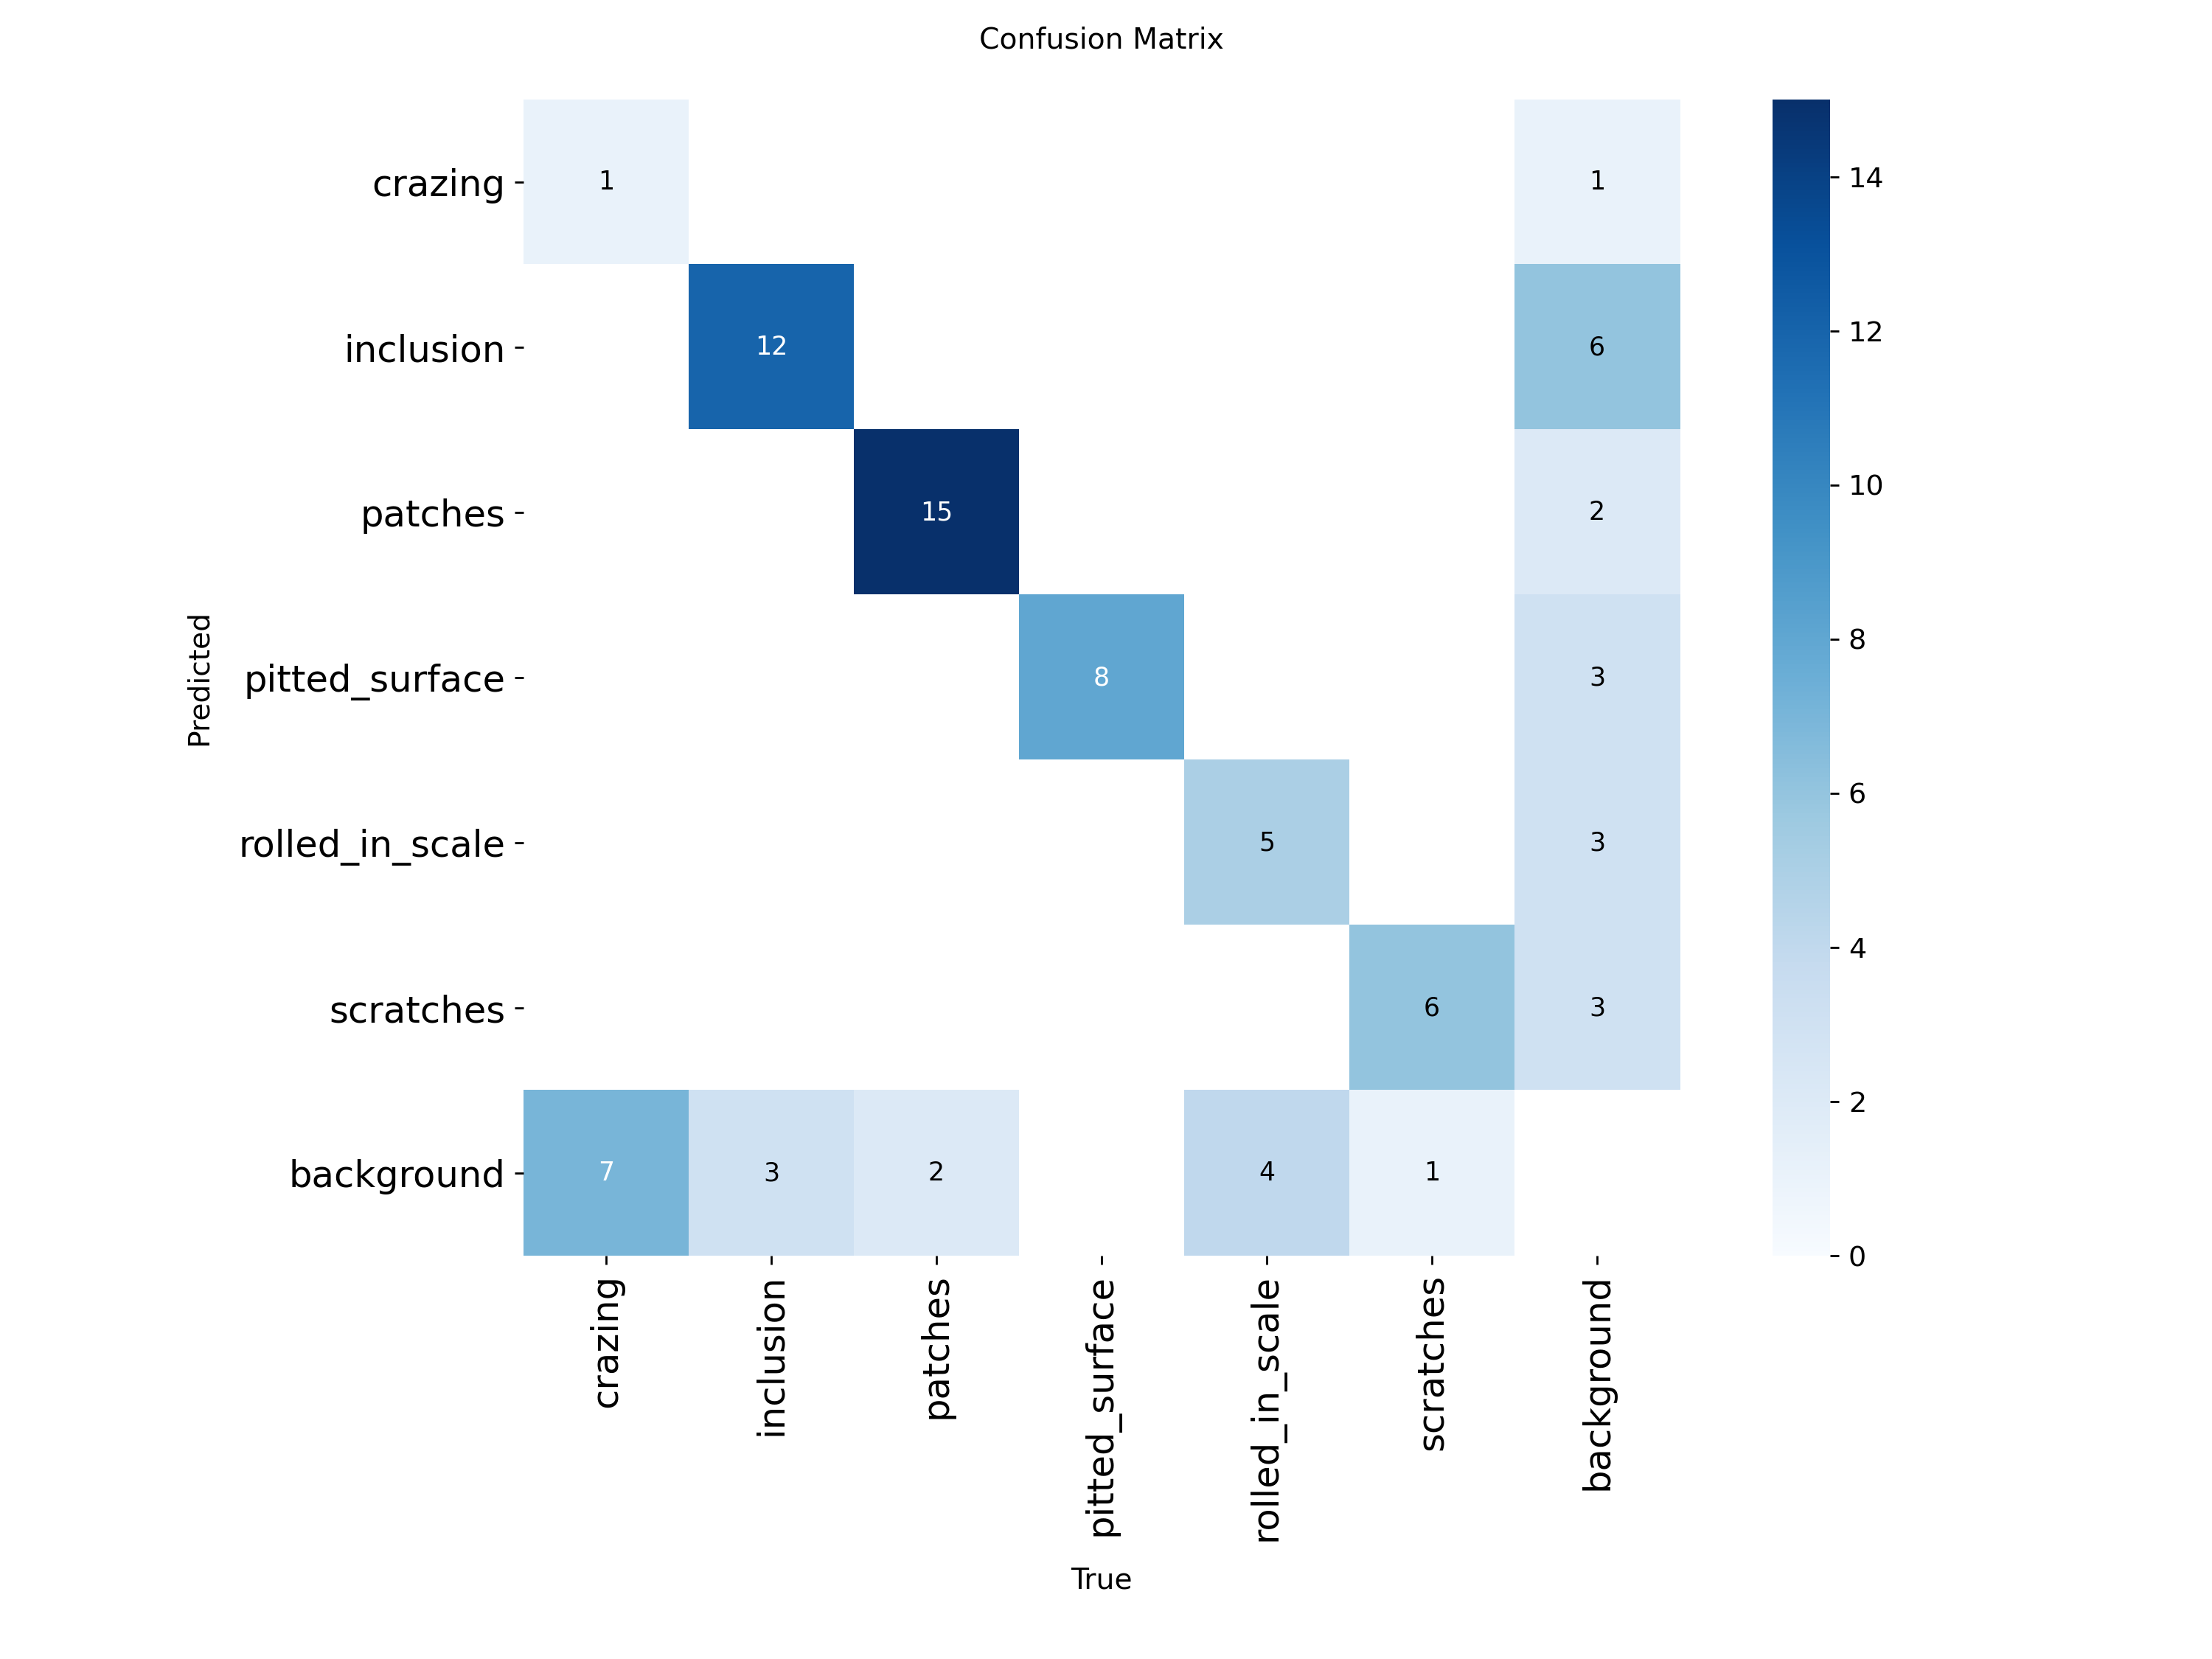

In [16]:
Image.open("runs/detect/runs/neu_yolo/confusion_matrix.png")

In [20]:
model.predict(
    source=f"{dataset_path}/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/crazing_1.jpg: 640x640 (no detections), 16.1ms
image 2/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/crazing_2.jpg: 640x640 2 crazings, 16.1ms
image 3/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 16.2ms
image 4/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/crazing_4.jpg: 640x640 (no detections), 16.1ms
image 5/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/crazing_5.jpg: 640x640 2 crazings, 16.1ms
image 6/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/inclusion_1.jpg: 640x640 5 inclusions, 16.1ms
image 7/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 16.1ms
image 8/30 /kaggle/input/datasets/diyadholakia/yolov8-soc/valid/valid/images/inclusion_3.jpg: 640x640 4 inclusions, 16.1ms
image 9/30 /kaggle/i

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled_in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

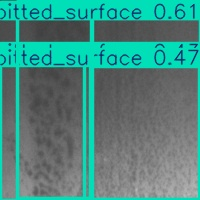

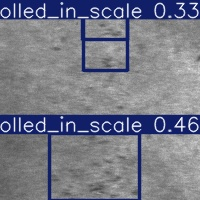

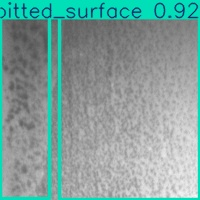

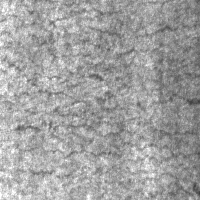

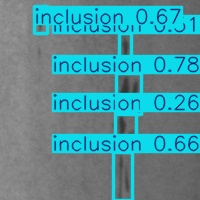

In [22]:
import glob

prediction_folder = glob.glob("runs/detect/predict*")[-1]

images = glob.glob(f"{prediction_folder}/*.jpg") + glob.glob(f"{prediction_folder}/*.png")

for img in images[:5]:
    display(Image.open(img))

In [23]:
import shutil

shutil.make_archive("YOLO_Assignment", "zip", "runs")

'/kaggle/working/YOLO_Assignment.zip'

In [25]:
import pandas as pd

df = pd.read_csv("runs/detect/runs/neu_yolo/results.csv")
df.tail()
best = df.loc[df["metrics/precision(B)"].idxmax()]
print(best[["epoch", "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]])

epoch                   29.00000
metrics/precision(B)     0.91585
metrics/recall(B)        0.66617
metrics/mAP50(B)         0.75543
metrics/mAP50-95(B)      0.47127
Name: 28, dtype: float64
